<a href="https://colab.research.google.com/github/eruskkii/telco-customer-churn-prediction/blob/main/Telco_customer_churn_Prediction_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost

In [ ]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import matplotlib.gridspec as gridspec

import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv


In [ ]:
df = pd.read_csv("Telco-Customer-Churn.csv")

## Section A — Data Understanding
Here we load the dataset and get our first look at it. Before doing
any cleaning or modelling, we need to understand what each column
means and what kind of data we're working with.

In [ ]:
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn names:\n{list(df.columns)}")
print(f"\nFirst 3 rows:")
df.head(3)

Shape: 7043 rows × 21 columns

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 3 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## Section B — Data Quality Assessment
Before cleaning anything, we need to investigate the data for problems.
We check for missing values, wrong data types, duplicates, and anything
that looks suspicious. We don't fix anything yet — just diagnose.

In [ ]:
print("=== Data Types ===")
print(df.dtypes)

=== Data Types ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


TotalCharges is meant to carry numbers, but it's showing objects. So we need to clean the data

In [ ]:
# Find rows where TotalCharges cannot be converted to a number
problem_rows = df[df["TotalCharges"].str.strip() == ""]
print(f"Number of problematic rows: {len(problem_rows)}")
print(problem_rows[["customerID", "tenure", "MonthlyCharges", "TotalCharges"]])

Number of problematic rows: 11
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
3331  7644-OMVMY       0           19.85             
3826  3213-VVOLG       0           25.35             
4380  2520-SGTTA       0           20.00             
5218  2923-ARZLG       0           19.70             
6670  4075-WKNIU       0           73.35             
6754  2775-SEFEE       0           61.90             


## Section C — Data Cleaning
Now we fix the problems we found. Every decision is explained.


In [ ]:
# Step 1: Convert TotalCharges to numeric
# The errors='coerce' argument turns any non-numeric value into NaN
# so we can then fill them properly
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Step 2: Fill the 11 NaN values with 0
# These are new customers (tenure=0) who haven't been billed yet

df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Step 3: Drop customerID — it's a unique identifier, not a pattern
# No two customers share an ID, so the model can't learn anything from it
df = df.drop(columns=["customerID"])

# Step 4: Encode the target column Churn as 0 and 1
# Models need numbers, not text. Yes=1 (churned), No=0 (stayed)
df["Churn"] = (df["Churn"] == "Yes").astype(int)

# Confirm everything looks clean
print(f"Remaining nulls: {df['TotalCharges'].isnull().sum()}")
print(f"TotalCharges dtype is now: {df['TotalCharges'].dtype}")
print(f"Churn unique values: {df['Churn'].unique()}")
print(f"Shape after cleaning: {df.shape}")

Remaining nulls: 0
TotalCharges dtype is now: float64
Churn unique values: [0 1]
Shape after cleaning: (7043, 20)


## Section D — Exploratory Data Analysis
Before building any model, we explore the data visually.
We want to understand which customer attributes are associated
with churn, so our later decisions (feature engineering, model
choice) are guided by evidence, not guesswork.

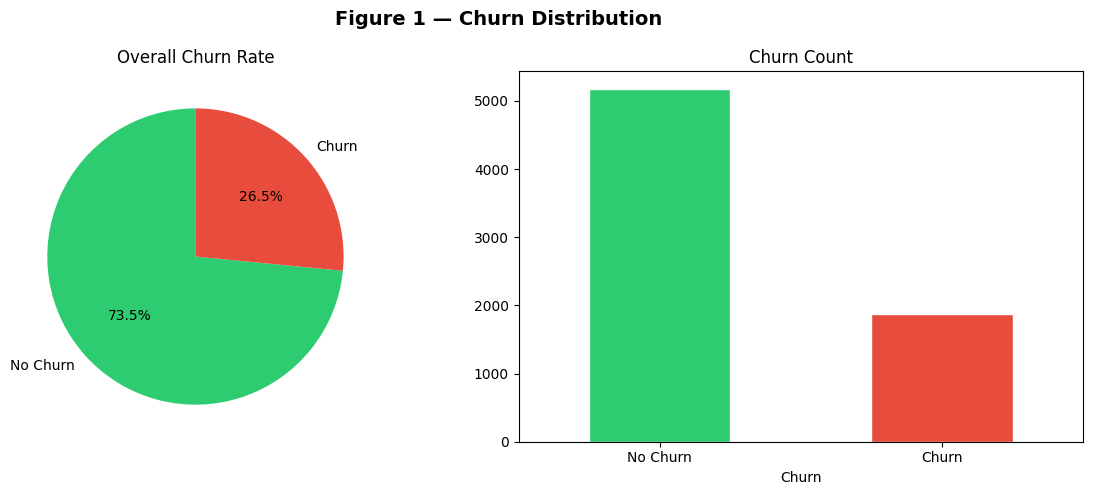

Churn rate: 26.5%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Figure 1 — Churn Distribution", fontsize=14, fontweight="bold")

# Pie chart
labels = ["No Churn", "Churn"]
sizes = df["Churn"].value_counts().values
colors = ["#2ECC71", "#E74C3C"]
axes[0].pie(sizes, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90)
axes[0].set_title("Overall Churn Rate")

# Bar chart
df["Churn"].value_counts().plot(kind="bar", ax=axes[1], color=colors, edgecolor="white")
axes[1].set_title("Churn Count")
axes[1].set_xticklabels(["No Churn", "Churn"], rotation=0)

plt.tight_layout()
plt.show()

print(f"Churn rate: {df['Churn'].mean():.1%}")

Because the dataset is imbalanced at 73.5% / 26.5%, accuracy alone is a misleading metric. A model predicting 'No Churn' for every customer would achieve 73.5% accuracy while being completely useless to the business. We therefore prioritise Recall and ROC-AUC.

### Plot 2 — Numeric Features by Churn
We look at how tenure, MonthlyCharges, and TotalCharges
distribute differently between churners and non-churners.
We use KDE plots (density curves) rather than histograms
because they show the shape of the distribution more smoothly.

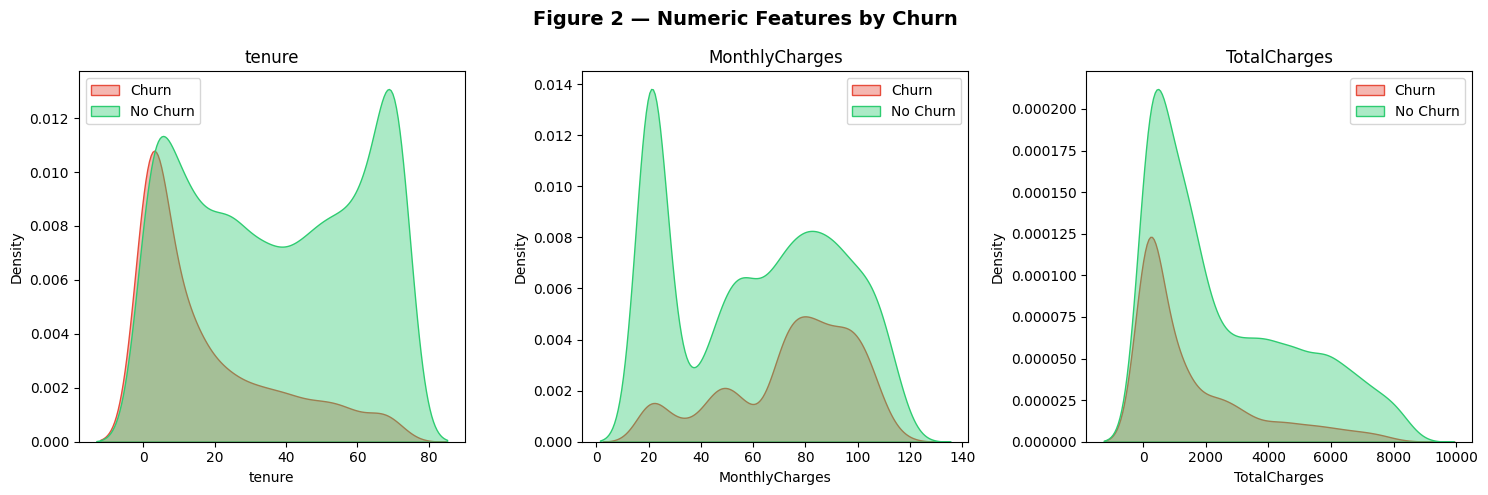

In [ ]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Figure 2 — Numeric Features by Churn", fontsize=14, fontweight="bold")

for i, col in enumerate(num_cols):
    sns.kdeplot(data=df, x=col, hue="Churn", ax=axes[i],
                palette={0: "#2ECC71", 1: "#E74C3C"}, fill=True, alpha=0.4)
    axes[i].set_title(col)
    axes[i].legend(["Churn", "No Churn"])

plt.tight_layout()
plt.show()

### Plot 3 — Contract & Payment Method vs Churn
We look at how contract length and payment method
relate to churn. These are categorical variables so
instead of KDE curves we use grouped bar charts showing
the churn rate within each category.

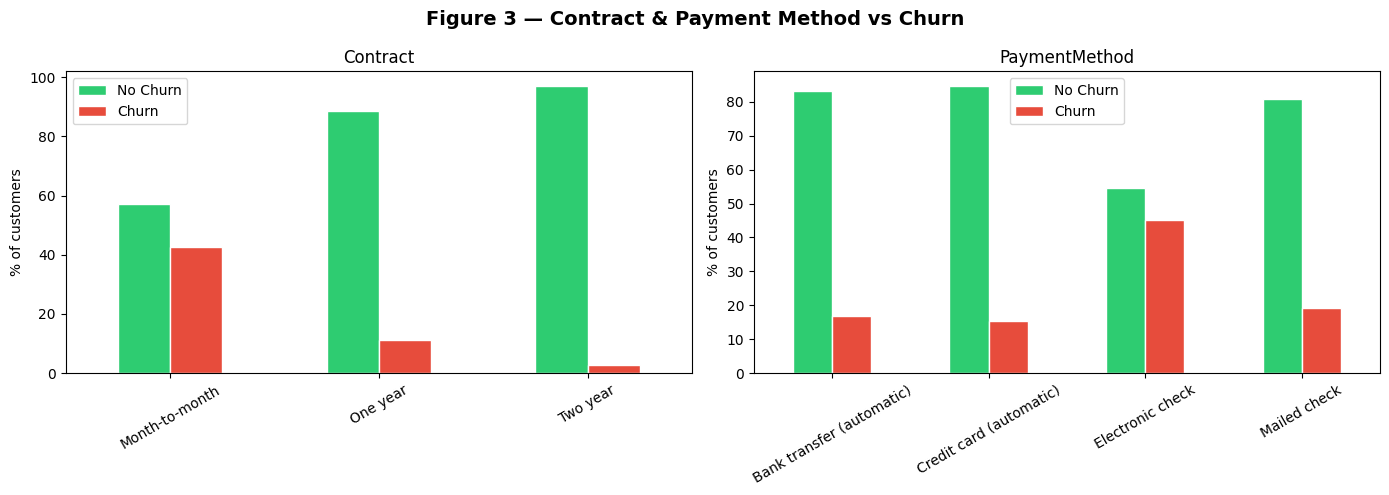

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 3 — Contract & Payment Method vs Churn", fontsize=14, fontweight="bold")

for ax, col in zip(axes, ["Contract", "PaymentMethod"]):
    # Calculate churn rate within each category as a percentage
    ct = pd.crosstab(df[col], df["Churn"], normalize="index") * 100
    ct.plot(kind="bar", ax=ax, color=["#2ECC71", "#E74C3C"], edgecolor="white")
    ax.set_title(col)
    ax.set_ylabel("% of customers")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(["No Churn", "Churn"])

plt.tight_layout()
plt.show()

### Plot 4 — Service Add-ons vs Churn Rate
Here we look at how each individual service subscription
relates to churn. We calculate the churn rate within each
category of each service column and display them as bar charts.
This helps us understand which services are associated with
higher or lower customer retention.

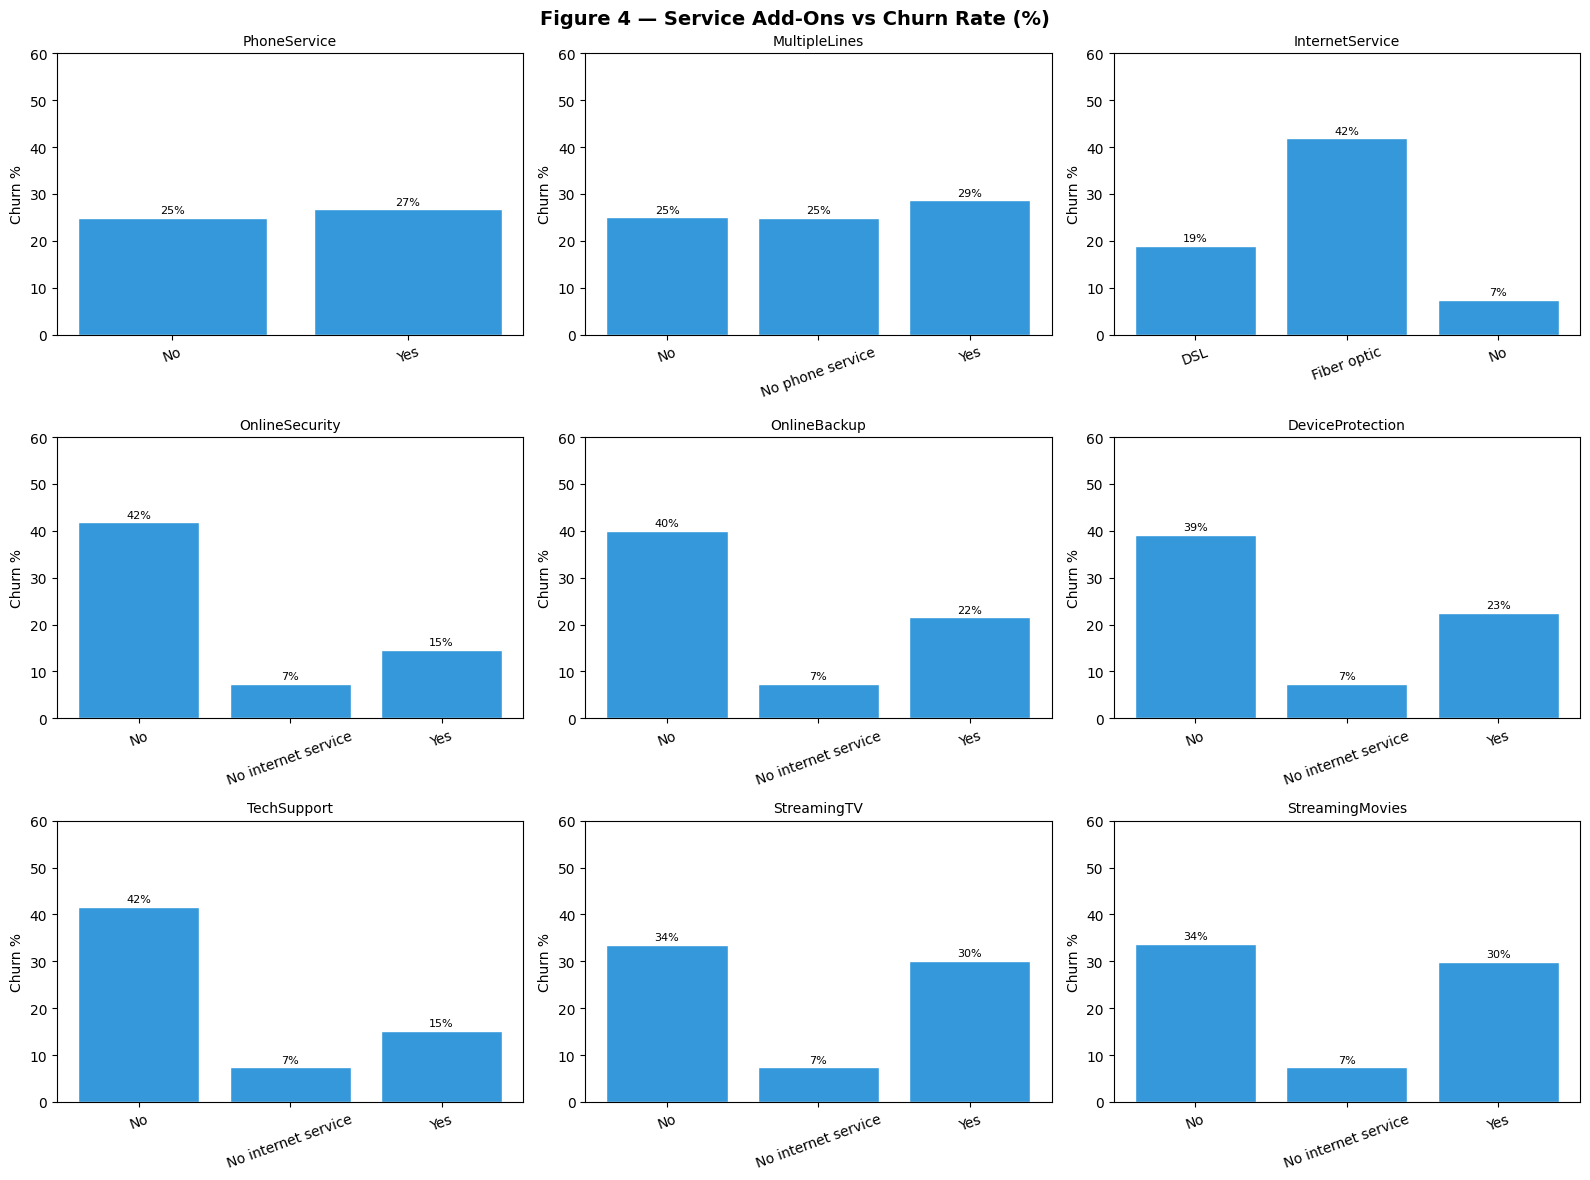

In [ ]:
service_cols = ["PhoneService", "MultipleLines", "InternetService",
                "OnlineSecurity", "OnlineBackup", "DeviceProtection",
                "TechSupport", "StreamingTV", "StreamingMovies"]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle("Figure 4 — Service Add-Ons vs Churn Rate (%)", fontsize=14, fontweight="bold")

for ax, col in zip(axes.flatten(), service_cols):
    rates = df.groupby(col)["Churn"].mean() * 100
    bars = ax.bar(rates.index, rates.values, color="#3498DB", edgecolor="white")
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("Churn %")
    ax.set_ylim(0, 60)
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 1,
                f"{val:.0f}%", ha="center", fontsize=8)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

"Protective and support services create genuine loyalty because they solve real problems customers fear losing. Entertainment add-ons create no such loyalty because alternatives exist everywhere outside the telco."

### Plot 5 — Correlation Heatmap
A correlation heatmap shows us how numeric variables
relate to each other and to our target variable (Churn).
Values close to 1 mean strong positive relationship,
values close to -1 mean strong negative relationship,
and values close to 0 mean little to no relationship.

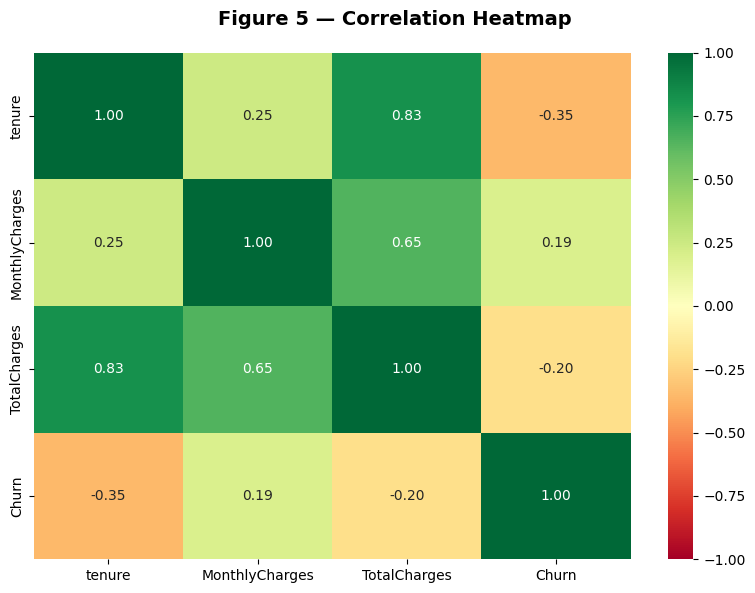

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle("Figure 5 — Correlation Heatmap", fontsize=14, fontweight="bold")

num_df = df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]
sns.heatmap(num_df.corr(), annot=True, fmt=".2f",
            cmap="RdYlGn", ax=ax, vmin=-1, vmax=1)

plt.tight_layout()
plt.show()

## Section E — Feature Engineering
Raw columns don't always capture the full picture.
Here we create new features based on our EDA findings
and business understanding. Every feature has a reason
— we don't create variables randomly.

In [ ]:
# Always work on a copy so our clean df stays intact
dfe = df.copy()

# FE-1: Number of protective services
# EDA showed security/support/backup dramatically reduce churn
# Instead of having 4 separate yes/no columns, we capture
# how "protected" a customer is as a single score
protective_services = ["OnlineSecurity", "OnlineBackup",
                       "DeviceProtection", "TechSupport"]
for col in protective_services:
    dfe[col + "_bin"] = (dfe[col] == "Yes").astype(int)

dfe["NumProtectiveServices"] = dfe[[c + "_bin" for c in protective_services]].sum(axis=1)
print("FE-1: NumProtectiveServices sample:")
print(dfe["NumProtectiveServices"].value_counts().sort_index())

FE-1: NumProtectiveServices sample:
NumProtectiveServices
0    2793
1    1467
2    1372
3     941
4     470
Name: count, dtype: int64


In [ ]:
# FE-2: Tenure Group
# EDA showed churn is heavily front-loaded in early months
# We bucket tenure into meaningful business segments
dfe["TenureGroup"] = pd.cut(dfe["tenure"],
                             bins=[-1, 12, 36, 72],
                             labels=["New", "Growing", "Loyal"])
print("FE-2: TenureGroup")
print(dfe["TenureGroup"].value_counts())

# FE-3: Contract Risk Score
# We convert contract type into an ordered risk number
# Month-to-month=2 (highest risk), One year=1, Two year=0 (lowest)
contract_map = {"Month-to-month": 2, "One year": 1, "Two year": 0}
dfe["ContractRisk"] = dfe["Contract"].map(contract_map)
print("\nFE-3: ContractRisk")
print(dfe["ContractRisk"].value_counts().sort_index())

# FE-4: Is High Spender
# EDA showed customers paying $80-100/month churn more
# We flag the top 25% of spenders explicitly
high_spend_thresh = dfe["MonthlyCharges"].quantile(0.75)
dfe["IsHighSpender"] = (dfe["MonthlyCharges"] >= high_spend_thresh).astype(int)
print(f"\nFE-4: IsHighSpender (threshold = ${high_spend_thresh:.2f})")
print(dfe["IsHighSpender"].value_counts())

# FE-5: Has Any Protective Service
# A simple yes/no version of NumProtectiveServices
# Sometimes a binary flag is more useful than a count
dfe["HasProtection"] = (dfe["NumProtectiveServices"] > 0).astype(int)
print("\nFE-5: HasProtection")
print(dfe["HasProtection"].value_counts())

# FE-6: Is Automatic Payment
# EDA showed automatic payments strongly associated with retention
dfe["IsAutoPayment"] = dfe["PaymentMethod"].isin(
    ["Bank transfer (automatic)", "Credit card (automatic)"]
).astype(int)
print("\nFE-6: IsAutoPayment")
print(dfe["IsAutoPayment"].value_counts())

print(f"\nTotal features before engineering: {df.shape[1]-1}")
print(f"Total features after engineering: {dfe.shape[1]-1}")

FE-2: TenureGroup
TenureGroup
Loyal      3001
New        2186
Growing    1856
Name: count, dtype: int64

FE-3: ContractRisk
ContractRisk
0    1695
1    1473
2    3875
Name: count, dtype: int64

FE-4: IsHighSpender (threshold = $89.85)
IsHighSpender
0    5272
1    1771
Name: count, dtype: int64

FE-5: HasProtection
HasProtection
1    4250
0    2793
Name: count, dtype: int64

FE-6: IsAutoPayment
IsAutoPayment
0    3977
1    3066
Name: count, dtype: int64

Total features before engineering: 19
Total features after engineering: 29


## Section F — Data Preparation
Before training any model, we need to prepare the data correctly.
This means encoding remaining categorical variables, splitting into
train and test sets, and scaling numeric features.
The golden rule: the test set must never influence anything
we do during training. It represents unseen future data.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Step 1: Drop the helper binary columns we created during FE
# They've served their purpose (building NumProtectiveServices)
# Keeping them would be redundant
drop_cols = [c + "_bin" for c in protective_services]
dfe = dfe.drop(columns=drop_cols)

# Step 2: Separate features (X) from target (y)
# X = everything the model learns FROM
# y = what the model is trying to predict
X = dfe.drop(columns=["Churn"])
y = dfe["Churn"]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns:\n{list(X.columns)}")

Features shape: (7043, 25)
Target shape: (7043,)

Feature columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'NumProtectiveServices', 'TenureGroup', 'ContractRisk', 'IsHighSpender', 'HasProtection', 'IsAutoPayment']


In [ ]:
# Step 3: Encode remaining categorical columns
# Models can't process text — everything must be numeric
# We use LabelEncoder for remaining text columns
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")

le = LabelEncoder()
X_encoded = X.copy()
for col in cat_cols:
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

print(f"\nAfter encoding, all dtypes numeric:")
print(X_encoded.dtypes)

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']

After encoding, all dtypes numeric:
gender                     int64
SeniorCitizen              int64
Partner                    int64
Dependents                 int64
tenure                     int64
PhoneService               int64
MultipleLines              int64
InternetService            int64
OnlineSecurity             int64
OnlineBackup               int64
DeviceProtection           int64
TechSupport                int64
StreamingTV                int64
StreamingMovies            int64
Contract                   int64
PaperlessBilling           int64
PaymentMethod              int64
MonthlyCharges           float64
TotalCharges             float64
NumProtectiveServices      int64
TenureGroup      

In [ ]:
# Step 4: Train/Test Split
# We split BEFORE scaling — this is critically important
# 80% of data for training, 20% held back for final evaluation
# stratify=y ensures both sets have the same 26.5% churn rate
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set:  {X_train.shape[0]} rows — churn rate: {y_train.mean():.1%}")
print(f"Test set:      {X_test.shape[0]} rows — churn rate: {y_test.mean():.1%}")

Training set:  5634 rows — churn rate: 26.5%
Test set:      1409 rows — churn rate: 26.5%


In [ ]:
# Step 5: Scale numeric features
# Logistic Regression is sensitive to feature scale
# A feature ranging 0-8000 (TotalCharges) would dominate
# a feature ranging 0-4 (NumProtectiveServices) unfairly
# StandardScaler transforms each numeric column to
# mean=0 and standard deviation=1

num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# IMPORTANT: fit only on training data, then transform both
# Fitting on test data would be "data leakage"
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("Scaling complete.")
print(f"\nMonthlyCharges before scaling — mean: {X_train['MonthlyCharges'].mean():.2f}")
print(f"MonthlyCharges after scaling  — mean: {X_train_scaled['MonthlyCharges'].mean():.4f}")

Scaling complete.

MonthlyCharges before scaling — mean: 64.93
MonthlyCharges after scaling  — mean: -0.0000


## Section G — Model Building
We train four different models and compare them.
Training multiple models is important because no single
algorithm is always best — the data decides.
We use class_weight='balanced' to handle our 26.5% churn
imbalance, so models don't ignore the minority class.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import xgboost as xgb

# Define our four models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        max_depth=10,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        random_state=42
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
        eval_metric="logloss",
        random_state=42
    ),
}

print("Models defined successfully.")
print(f"\nHandling class imbalance:")
print(f"  Ratio of No Churn to Churn: {(y_train==0).sum()/(y_train==1).sum():.2f}")
print(f"  This is passed to XGBoost as scale_pos_weight")

Models defined successfully.

Handling class imbalance:
  Ratio of No Churn to Churn: 2.77
  This is passed to XGBoost as scale_pos_weight


### Model Training
We train each model using 5-fold cross validation on the
training set to get a reliable performance estimate.
Then we fit each model on the full training set and
evaluate on the held-out test set.

In [ ]:
from sklearn.metrics import (roc_auc_score, f1_score, recall_score,
                             precision_score, accuracy_score,
                             average_precision_score)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    # Use scaled data for Logistic Regression, unscaled for tree models
    X_tr = X_train_scaled if name == "Logistic Regression" else X_train
    X_te = X_test_scaled  if name == "Logistic Regression" else X_test

    # Step 1: Cross validation on training set
    cv_auc = cross_val_score(model, X_tr, y_train,
                             cv=cv, scoring="roc_auc")

    # Step 2: Fit on full training set
    model.fit(X_tr, y_train)

    # Step 3: Predict on test set
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    # Step 4: Store all results
    results[name] = {
        "model":          model,
        "y_pred":         y_pred,
        "y_prob":         y_prob,
        "cv_auc_mean":    cv_auc.mean(),
        "cv_auc_std":     cv_auc.std(),
        "test_auc":       roc_auc_score(y_test, y_prob),
        "test_f1":        f1_score(y_test, y_pred),
        "test_recall":    recall_score(y_test, y_pred),
        "test_precision": precision_score(y_test, y_pred),
        "test_accuracy":  accuracy_score(y_test, y_pred),
    }

    print(f"\n{name}")
    print(f"  CV ROC-AUC:   {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
    print(f"  Test ROC-AUC: {results[name]['test_auc']:.4f}")
    print(f"  Test Recall:  {results[name]['test_recall']:.4f}")
    print(f"  Test F1:      {results[name]['test_f1']:.4f}")


Logistic Regression
  CV ROC-AUC:   0.8464 ± 0.0118
  Test ROC-AUC: 0.8416
  Test Recall:  0.7807
  Test F1:      0.6147

Random Forest
  CV ROC-AUC:   0.8429 ± 0.0099
  Test ROC-AUC: 0.8377
  Test Recall:  0.6925
  Test F1:      0.6137

Gradient Boosting
  CV ROC-AUC:   0.8456 ± 0.0110
  Test ROC-AUC: 0.8425
  Test Recall:  0.5107
  Test F1:      0.5762

XGBoost
  CV ROC-AUC:   0.8454 ± 0.0099
  Test ROC-AUC: 0.8432
  Test Recall:  0.7861
  Test F1:      0.6222


## Section H — Model Evaluation
We evaluate our models using multiple metrics and
visualisations. Accuracy alone is misleading for
imbalanced datasets. We use ROC curves, a comparison
table, and a confusion matrix to fully understand
how each model is performing.

In [ ]:
print("=" * 65)
print(f"{'Model':<25} {'ROC-AUC':>8} {'Recall':>8} {'Precision':>10} {'F1':>8} {'Accuracy':>10}")
print("=" * 65)

for name, res in results.items():
    print(f"{name:<25} "
          f"{res['test_auc']:>8.4f} "
          f"{res['test_recall']:>8.4f} "
          f"{res['test_precision']:>10.4f} "
          f"{res['test_f1']:>8.4f} "
          f"{res['test_accuracy']:>10.4f}")

print("=" * 65)
print("\n* We prioritise Recall because missing a churner")
print("  costs more than a false alarm.")
print("* Accuracy is included for completeness but is")
print("  misleading on imbalanced data.")

Model                      ROC-AUC   Recall  Precision       F1   Accuracy
Logistic Regression         0.8416   0.7807     0.5069   0.6147     0.7402
Random Forest               0.8377   0.6925     0.5511   0.6137     0.7686
Gradient Boosting           0.8425   0.5107     0.6609   0.5762     0.8006
XGBoost                     0.8432   0.7861     0.5149   0.6222     0.7466

* We prioritise Recall because missing a churner
  costs more than a false alarm.
* Accuracy is included for completeness but is
  misleading on imbalanced data.


### Confusion Matrix — XGBoost
The confusion matrix shows exactly where our best model
is right and wrong. Each cell tells us a specific type
of correct or incorrect prediction.

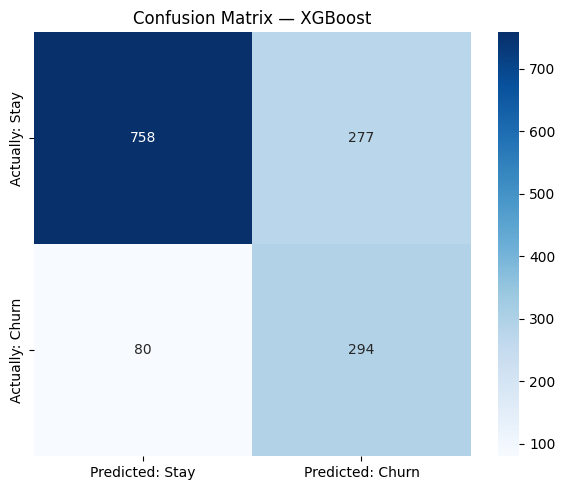

True Negatives  (correctly said Stay):  758
False Positives (wrongly flagged Churn): 277
False Negatives (missed churners):       80
True Positives  (correctly caught):      294

Of 374 actual churners, we caught 294 (78.6%)
Of 1035 actual stayers, we wrongly flagged 277 (26.8%)


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

best_name = "XGBoost"
best_res = results[best_name]

cm = confusion_matrix(y_test, best_res["y_pred"])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Predicted: Stay", "Predicted: Churn"],
            yticklabels=["Actually: Stay", "Actually: Churn"])
ax.set_title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()

# Break down what each number means
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly said Stay):  {tn}")
print(f"False Positives (wrongly flagged Churn): {fp}")
print(f"False Negatives (missed churners):       {fn}")
print(f"True Positives  (correctly caught):      {tp}")
print(f"\nOf {tp+fn} actual churners, we caught {tp} ({tp/(tp+fn):.1%})")
print(f"Of {fp+tn} actual stayers, we wrongly flagged {fp} ({fp/(fp+tn):.1%})")

In [ ]:
from sklearn.metrics import classification_report

for name, res in results.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, res["y_pred"],
                                target_names=["No Churn", "Churn"]))


  Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.80      1035
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


  Random Forest
              precision    recall  f1-score   support

    No Churn       0.88      0.80      0.83      1035
       Churn       0.55      0.69      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409


  Gradient Boosting
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.66      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg 

### ROC Curves
The ROC curve shows how well each model separates
churners from non-churners across all possible
thresholds. The closer the curve hugs the top-left
corner, the better. A diagonal line would mean the
model is no better than random guessing.

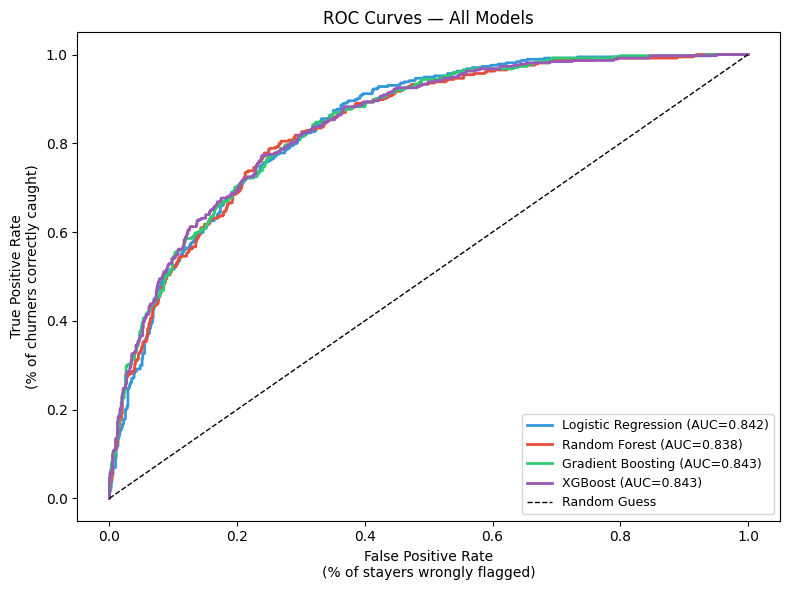

In [ ]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

plot_colors = ["#3498DB", "#E74C3C", "#2ECC71", "#9B59B6"]

for (name, res), color in zip(results.items(), plot_colors):
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    ax.plot(fpr, tpr,
            label=f"{name} (AUC={res['test_auc']:.3f})",
            color=color, lw=2)

# Diagonal line = random guessing baseline
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random Guess")

ax.set_xlabel("False Positive Rate\n(% of stayers wrongly flagged)")
ax.set_ylabel("True Positive Rate\n(% of churners correctly caught)")
ax.set_title("ROC Curves — All Models")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()